In [1]:
from dotenv import load_dotenv
import os
from entsoe import EntsoePandasClient
import pandas as pd
import matplotlib.pyplot as plt

load_dotenv()
api_key = os.getenv("ENTSOE_API_KEY")
client = EntsoePandasClient(api_key=api_key)
print("connected")

connected


In [2]:
from pandas import Timestamp

start = Timestamp("2024-01-01", tz="Europe/Vienna")
end = Timestamp("2024-12-31", tz="Europe/Vienna")

prices = client.query_day_ahead_prices("AT", start=start, end=end)
print(prices.head())

2024-01-01 00:00:00+01:00    0.10
2024-01-01 01:00:00+01:00    0.01
2024-01-01 02:00:00+01:00    0.02
2024-01-01 03:00:00+01:00    0.00
2024-01-01 04:00:00+01:00   -0.01
dtype: float64


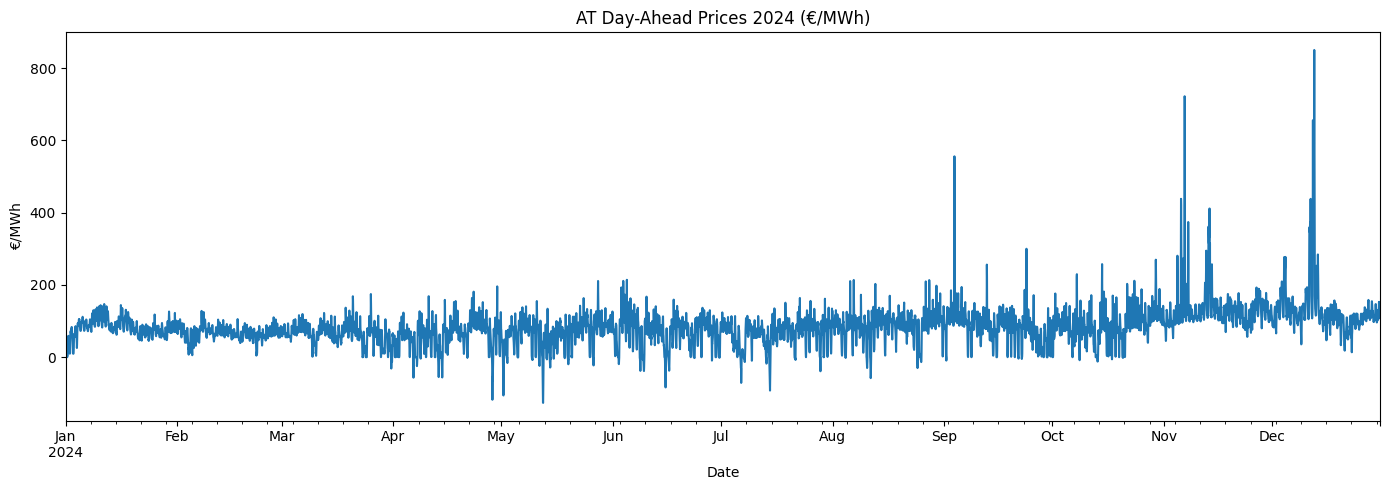

In [3]:
prices.plot(figsize=(14, 5), title="AT Day-Ahead Prices 2024 (€/MWh)")
plt.ylabel("€/MWh")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

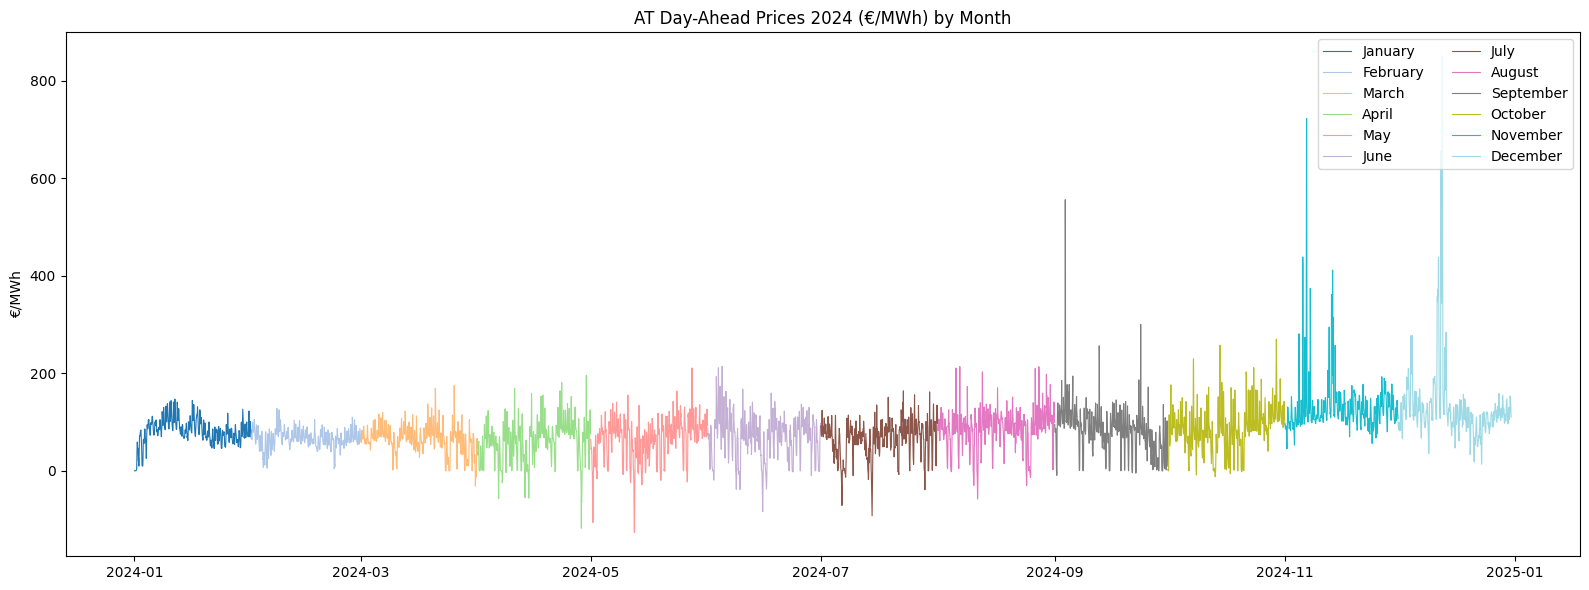

In [4]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, ax = plt.subplots(figsize=(16, 6))

colors = cm.tab20(np.linspace(0, 1, 12))

for i, month in enumerate(range(1, 13)):
    monthly = prices[prices.index.month == month]
    ax.plot(monthly.index, monthly.values, color=colors[i], 
            label=monthly.index[0].strftime("%B"), linewidth=0.8)

ax.set_title("AT Day-Ahead Prices 2024 (€/MWh) by Month")
ax.set_ylabel("€/MWh")
ax.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

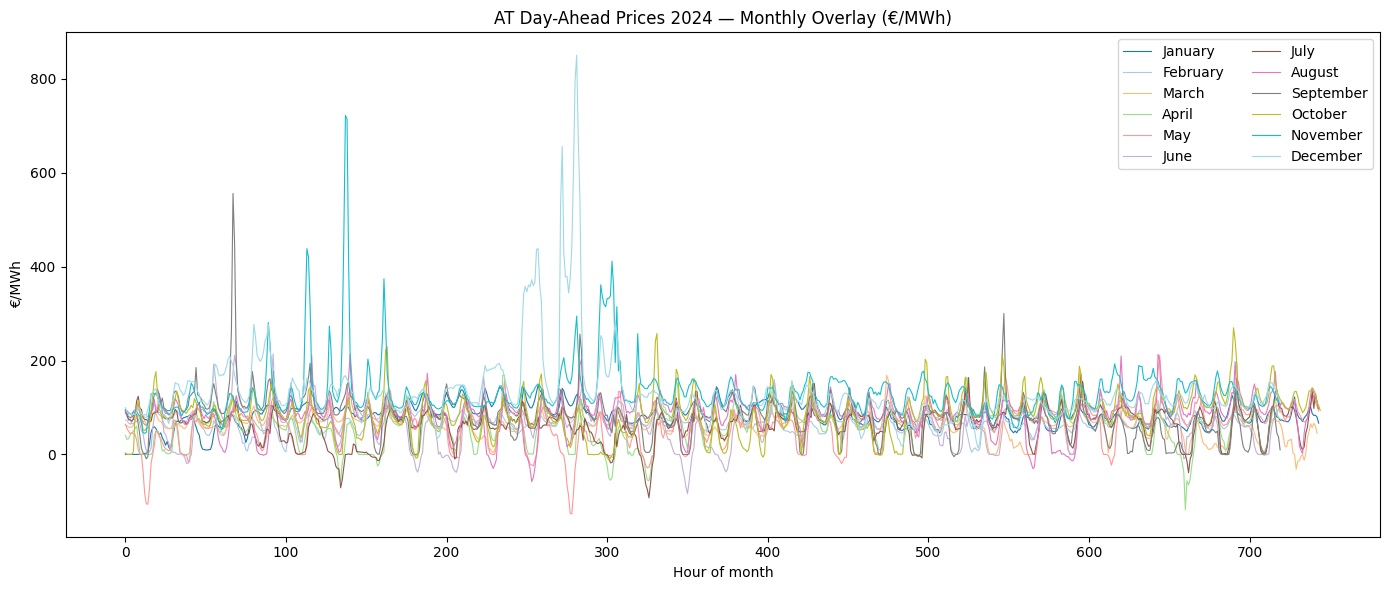

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = cm.tab20(np.linspace(0, 1, 12))

for i, month in enumerate(range(1, 13)):
    monthly = prices[prices.index.month == month]
    monthly_reset = monthly.reset_index(drop=True)
    ax.plot(monthly_reset.values, color=colors[i],
            label=monthly.index[0].strftime("%B"), linewidth=0.8)

ax.set_title("AT Day-Ahead Prices 2024 — Monthly Overlay (€/MWh)")
ax.set_ylabel("€/MWh")
ax.set_xlabel("Hour of month")
ax.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

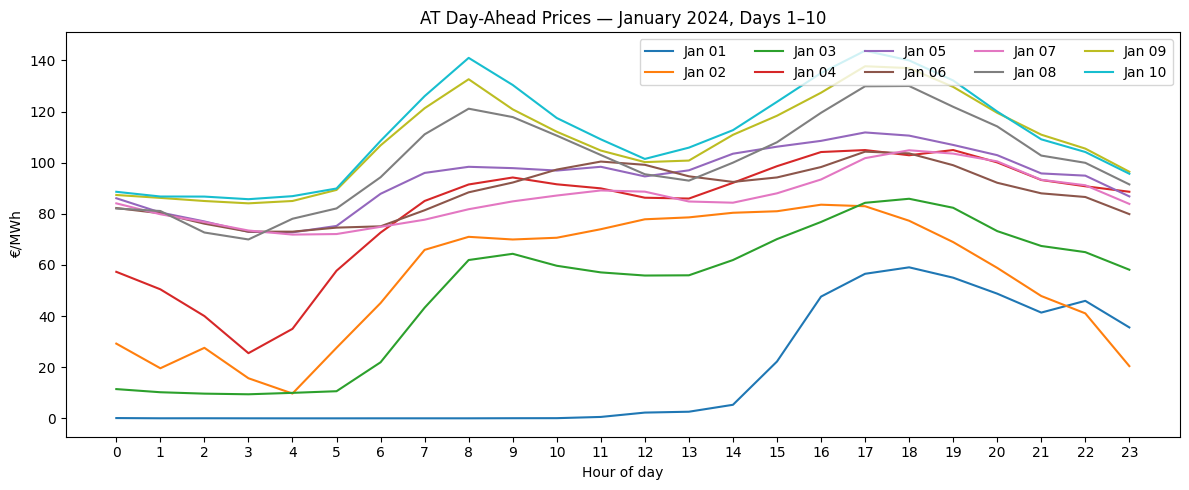

In [6]:
january = prices[prices.index.month == 1]

fig, ax = plt.subplots(figsize=(12, 5))

colors10 = plt.cm.tab10.colors
for day in range(1, 11):
    day_data = january[january.index.day == day]
    ax.plot(range(len(day_data)), day_data.values, color=colors10[day - 1], label=f"Jan {day:02d}")

ax.set_title("AT Day-Ahead Prices — January 2024, Days 1–10")
ax.set_ylabel("€/MWh")
ax.set_xlabel("Hour of day")
ax.set_xticks(range(24))
ax.legend(loc="upper right", ncol=5)
plt.tight_layout()
plt.show()